# 03 — Ant Colony Optimization aplicado al ATSP

**Variante del TSP — Notebook 3 de 5**

En el ATSP la feromona debe almacenarse por **arco dirigido**. Depositar feromona
en `i → j` no refuerza automáticamente `j → i`. Esta diferencia es la adaptación
central respecto del TSP simétrico.

## Qué se aprenderá
1. Construcción probabilística de recorridos dirigidos.
2. Feromona y heurística independientes para cada dirección.
3. Evaporación y depósito elitista.
4. Escalamiento con 10, 20, 50 y 100 ciudades.

## Semillas dinámicas de esta versión
- `MASTER_SEED = None` genera una variante nueva cada vez que se ejecuta todo.
- Cada tamaño utiliza semillas independientes y estas se imprimen antes de resolverlo.
- Para repetir una ejecución, copia la semilla maestra impresa y colócala en `MASTER_SEED`.


## 1. Variante estudiada: TSP asimétrico (ATSP)

En el TSP tradicional suele suponerse que la distancia es simétrica:

$$c_{ij}=c_{ji}.$$

En el **Asymmetric Traveling Salesman Problem (ATSP)** esta igualdad no se exige:

$$c_{ij}\neq c_{ji}.$$

Esto representa situaciones reales como calles de un solo sentido, pendientes,
peajes diferentes, viento, congestión o tiempos de viaje dependientes de la
dirección. Se busca una permutación de todas las ciudades que minimice

$$f(\pi)=\sum_{k=0}^{n-1}c_{\pi_k,\pi_{(k+1)\bmod n}}.$$

Los tres tamaños usados son **10, 20, 50 y 100 ciudades**. En cada ejecución se crea una **semilla maestra nueva** y, a partir de ella,
semillas independientes para las instancias y los componentes aleatorios. Todas
se imprimen y se guardan en las tablas. Para repetir un resultado basta con copiar
la semilla maestra mostrada y asignarla a `MASTER_SEED`.


In [ ]:
%matplotlib inline
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_atsp_instance(n, seed=42, asymmetry=0.40):
    """Crea coordenadas y una matriz de costos dirigida para un ATSP."""
    rng = np.random.default_rng(seed)
    coords = rng.uniform(0, 100, size=(n, 2))
    delta = coords[:, None, :] - coords[None, :, :]
    euclidean = np.sqrt((delta ** 2).sum(axis=2))

    # Cada arco recibe un factor direccional independiente.
    directional_factor = 1.0 + asymmetry * rng.uniform(-1.0, 1.0, size=(n, n))
    D = euclidean * directional_factor
    np.fill_diagonal(D, np.inf)
    return coords, D


def tour_cost(tour, D):
    tour = np.asarray(tour, dtype=int)
    return float(D[tour, np.roll(tour, -1)].sum())


def validate_tour(tour, n):
    tour = np.asarray(tour, dtype=int)
    return len(tour) == n and np.array_equal(np.sort(tour), np.arange(n))


def nearest_neighbor(D, start=0):
    """Solución inicial rápida respetando los costos dirigidos."""
    n = len(D)
    unvisited = set(range(n))
    unvisited.remove(start)
    tour = [start]
    while unvisited:
        last = tour[-1]
        nxt = min(unvisited, key=lambda j: D[last, j])
        tour.append(nxt)
        unvisited.remove(nxt)
    return np.asarray(tour, dtype=int)


def random_tour(n, rng):
    """Fija la ciudad 0 al comienzo para eliminar rotaciones equivalentes."""
    return np.r_[0, rng.permutation(np.arange(1, n))]


def asymmetry_index(D):
    """Promedio relativo de |c_ij-c_ji| sobre los arcos fuera de la diagonal."""
    n = len(D)
    mask = ~np.eye(n, dtype=bool)
    forward = D[mask]
    reverse = D.T[mask]
    denom = np.maximum((forward + reverse) / 2.0, 1e-12)
    return float(np.mean(np.abs(forward - reverse) / denom))


def plot_directed_tour(coords, tour, title='', ax=None):
    """Dibuja el ciclo e indica su orientación con flechas."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    tour = np.asarray(tour, dtype=int)
    closed = np.r_[tour, tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], '-o', linewidth=1.3, markersize=4)
    dx = xy[1:, 0] - xy[:-1, 0]
    dy = xy[1:, 1] - xy[:-1, 1]
    ax.quiver(xy[:-1, 0], xy[:-1, 1], dx, dy,
              angles='xy', scale_units='xy', scale=1,
              width=0.003, alpha=0.65)
    if len(coords) <= 20:
        for i, (x, y) in enumerate(coords):
            ax.annotate(str(i), (x, y), xytext=(4, 4),
                        textcoords='offset points', fontsize=8)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    return ax

MASTER_SEED = None

if MASTER_SEED is None:
    RUN_SEED = int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])
else:
    RUN_SEED = int(MASTER_SEED)

seed_rng = np.random.default_rng(RUN_SEED)
SIZES = [10, 20, 50, 100]


def next_seed():
    """Entrega una semilla uint32 independiente y compatible con NumPy."""
    return int(seed_rng.integers(0, 2**32, dtype=np.uint32))


INSTANCE_SEEDS = {n: next_seed() for n in SIZES}
START_SEEDS = {n: next_seed() for n in SIZES}
TEMPERATURE_SEEDS = {n: next_seed() for n in SIZES}
ALGORITHM_SEEDS = {n: next_seed() for n in SIZES}

INSTANCES = {
    n: make_atsp_instance(n, seed=INSTANCE_SEEDS[n], asymmetry=0.40)
    for n in SIZES
}

seed_table = pd.DataFrame({
    'n': SIZES,
    'semilla_instancia': [INSTANCE_SEEDS[n] for n in SIZES],
    'semilla_inicio': [START_SEEDS[n] for n in SIZES],
    'semilla_temperatura': [TEMPERATURE_SEEDS[n] for n in SIZES],
    'semilla_algoritmo': [ALGORITHM_SEEDS[n] for n in SIZES],
})

print('=' * 72)
print(f'SEMILLA MAESTRA DE ESTA EJECUCIÓN: {RUN_SEED}')
print('Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.')
print('=' * 72)
display(seed_table)

for n, (_, D) in INSTANCES.items():
    print(
        f'n={n:3d} | semilla instancia={INSTANCE_SEEDS[n]:10d} | '
        f'asimetría={asymmetry_index(D):.3f} | '
        f'costo greedy={tour_cost(nearest_neighbor(D), D):.2f}'
    )


SEMILLA MAESTRA DE ESTA EJECUCIÓN: 1614182212
Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.


,n,semilla_instancia,semilla_inicio,semilla_temperatura,semilla_algoritmo
0,10,4282420734,4010749137,1718875786,139143022
1,20,1628077560,474318135,715964556,4280670135
2,50,3269386650,809027412,530966678,1359400860
3,100,3452484378,1006986286,2837240872,2782815197


n= 10 | semilla instancia=4282420734 | asimetría=0.258 | costo greedy=371.78
n= 20 | semilla instancia=1628077560 | asimetría=0.303 | costo greedy=471.94
n= 50 | semilla instancia=3269386650 | asimetría=0.269 | costo greedy=735.26
n=100 | semilla instancia=3452484378 | asimetría=0.269 | costo greedy=857.14


## 2. Desarrollo de Ant System dirigido

Una hormiga ubicada en `i` elige una ciudad no visitada `j` con probabilidad
proporcional a

$$\tau_{ij}^{\alpha}\left(\frac{1}{c_{ij}}\right)^{\beta}.$$

Después de construir los recorridos se evapora toda la matriz y cada hormiga
deposita `Q/L` únicamente sobre los arcos dirigidos que utilizó. También se
agrega un depósito elitista del mejor recorrido global.


In [2]:
def ant_system_atsp(D, n_ants=30, n_iter=80, alpha=1.0, beta=4.0,
                    rho=0.35, Q=1.0, elite_weight=2.0, seed=0):
    """Ant System para ATSP. La feromona es dirigida."""
    rng = np.random.default_rng(seed)
    n = len(D)

    eta = np.zeros_like(D)
    finite = np.isfinite(D)
    eta[finite] = 1.0 / np.maximum(D[finite], 1e-12)
    tau = np.ones((n, n), dtype=float)
    np.fill_diagonal(tau, 0.0)

    best_tour = None
    best_cost = np.inf
    history = []

    for _ in range(n_iter):
        tours = []
        costs = []

        for _ant in range(n_ants):
            start = int(rng.integers(n))
            tour = [start]
            visited = np.zeros(n, dtype=bool)
            visited[start] = True

            while len(tour) < n:
                i = tour[-1]
                weights = (tau[i] ** alpha) * (eta[i] ** beta)
                weights[visited] = 0.0
                total = weights.sum()

                if total <= 0 or not np.isfinite(total):
                    candidates = np.where(~visited)[0]
                    j = int(rng.choice(candidates))
                else:
                    j = int(rng.choice(n, p=weights / total))

                tour.append(j)
                visited[j] = True

            tour = np.asarray(tour, dtype=int)
            value = tour_cost(tour, D)
            tours.append(tour)
            costs.append(value)

            if value < best_cost:
                best_tour = tour.copy()
                best_cost = value

        tau *= (1.0 - rho)

        for tour, value in zip(tours, costs):
            deposit = Q / value
            for k in range(n):
                i = tour[k]
                j = tour[(k + 1) % n]
                tau[i, j] += deposit       # solo i -> j

        if best_tour is not None:
            elite_deposit = elite_weight * Q / best_cost
            for k in range(n):
                i = best_tour[k]
                j = best_tour[(k + 1) % n]
                tau[i, j] += elite_deposit

        history.append(best_cost)

    return best_tour, best_cost, history, tau


## 3. Ejemplo principal: 20 ciudades

Semilla maestra   : 1614182212
Semilla instancia : 1628077560
Semilla algoritmo : 4280670135
Mejor costo ACO : 389.765
Costo greedy    : 471.935
Ruta válida     : True


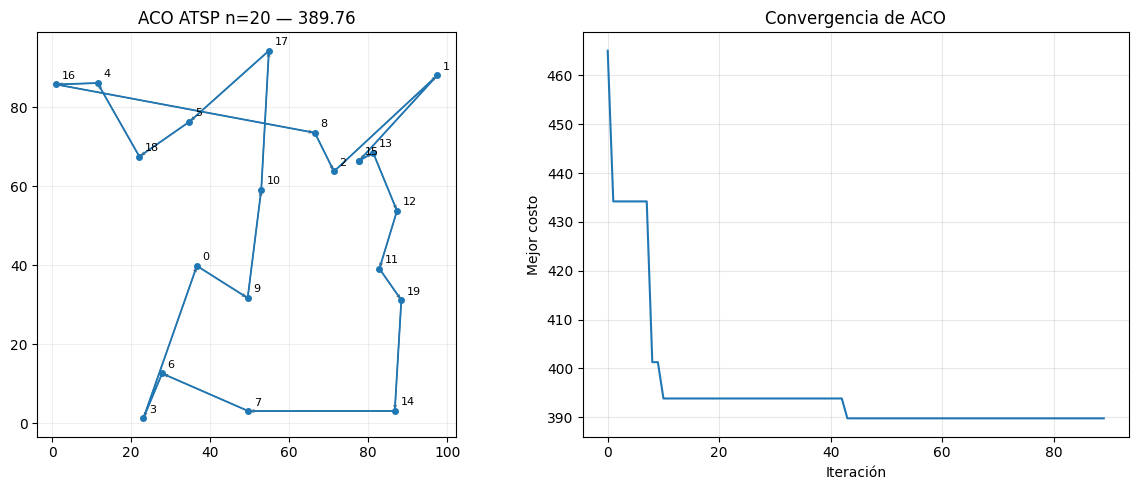

In [3]:
coords20, D20 = INSTANCES[20]
seed20 = ALGORITHM_SEEDS[20]

print(f'Semilla maestra   : {RUN_SEED}')
print(f'Semilla instancia : {INSTANCE_SEEDS[20]}')
print(f'Semilla algoritmo : {seed20}')

best20, value20, hist20, tau20 = ant_system_atsp(
    D20, n_ants=30, n_iter=90,
    alpha=1.0, beta=4.0, rho=0.35,
    elite_weight=2.0, seed=seed20
)

print(f'Mejor costo ACO : {value20:.3f}')
print(f'Costo greedy    : {tour_cost(nearest_neighbor(D20), D20):.3f}')
print(f'Ruta válida     : {validate_tour(best20, 20)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_directed_tour(coords20, best20, f'ACO ATSP n=20 — {value20:.2f}', ax=axes[0])
axes[1].plot(hist20)
axes[1].set_title('Convergencia de ACO')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Mejor costo')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Mapa de feromonas dirigidas

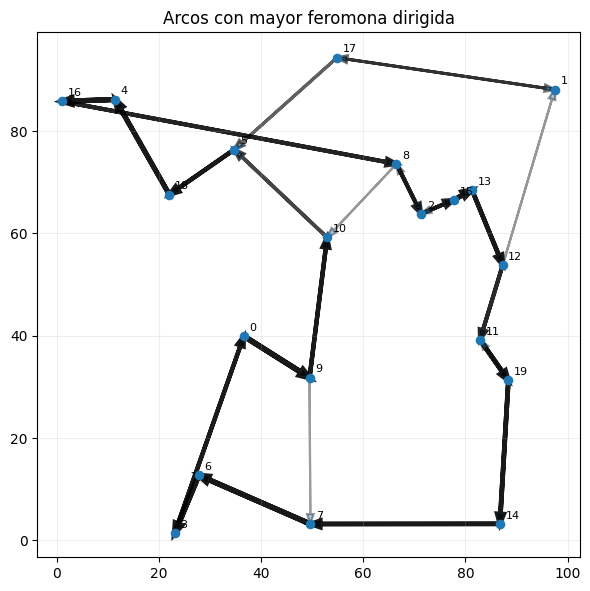

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
threshold = np.quantile(tau20[tau20 > 0], 0.93)
for i in range(20):
    for j in range(20):
        if i != j and tau20[i, j] >= threshold:
            x, y = coords20[i]
            dx, dy = coords20[j] - coords20[i]
            strength = tau20[i, j] / tau20.max()
            ax.arrow(x, y, dx, dy, length_includes_head=True,
                     head_width=1.3, alpha=min(0.9, 0.2 + strength),
                     linewidth=1 + 3 * strength)
ax.scatter(coords20[:, 0], coords20[:, 1], s=35, zorder=3)
for i, (x, y) in enumerate(coords20):
    ax.annotate(str(i), (x, y), xytext=(4, 4), textcoords='offset points', fontsize=8)
ax.set_title('Arcos con mayor feromona dirigida')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
plt.show()


## 4. Entradas de 10, 20, 50 y 100 ciudades

In [5]:
ACO_CONFIG = {
    10: {'ants': 20, 'iterations': 80},
    20: {'ants': 30, 'iterations': 90},
    50: {'ants': 40, 'iterations': 100},
    100: {'ants': 45, 'iterations': 110},
}

aco_results = []
aco_histories = {}
aco_solutions = {}
aco_pheromones = {}

for execution_id, n in enumerate(SIZES, start=1):
    coords, D = INSTANCES[n]
    cfg = ACO_CONFIG[n]
    algorithm_seed = ALGORITHM_SEEDS[n]
    baseline = tour_cost(nearest_neighbor(D), D)

    print('\n' + '-' * 72)
    print(f'Ejecución {execution_id}/{len(SIZES)} — ACO — n={n}')
    print(f'Semilla de instancia : {INSTANCE_SEEDS[n]}')
    print(f'Semilla de algoritmo : {algorithm_seed}')

    t0 = time.perf_counter()
    best, value, history, tau = ant_system_atsp(
        D,
        n_ants=cfg['ants'],
        n_iter=cfg['iterations'],
        alpha=1.0,
        beta=4.0,
        rho=0.35,
        elite_weight=2.0,
        seed=algorithm_seed,
    )
    elapsed = time.perf_counter() - t0

    aco_solutions[n] = best
    aco_histories[n] = history
    aco_pheromones[n] = tau
    aco_results.append({
        'ejecucion': execution_id,
        'n': n,
        'semilla_maestra': RUN_SEED,
        'semilla_instancia': INSTANCE_SEEDS[n],
        'semilla_algoritmo': algorithm_seed,
        'costo_greedy': baseline,
        'mejor_costo': value,
        'mejora_%': 100 * (baseline - value) / baseline,
        'hormigas': cfg['ants'],
        'iteraciones': cfg['iterations'],
        'tiempo_s': elapsed,
    })

    print(f'Mejor costo          : {value:.3f}')
    print(f'Tiempo               : {elapsed:.3f} s')

aco_df = pd.DataFrame(aco_results)
display(aco_df.round({
    'costo_greedy': 2,
    'mejor_costo': 2,
    'mejora_%': 2,
    'tiempo_s': 3,
}))



------------------------------------------------------------------------
Ejecución 1/4 — ACO — n=10
Semilla de instancia : 4282420734
Semilla de algoritmo : 139143022
Mejor costo          : 277.348
Tiempo               : 1.481 s

------------------------------------------------------------------------
Ejecución 2/4 — ACO — n=20
Semilla de instancia : 1628077560
Semilla de algoritmo : 4280670135
Mejor costo          : 389.765
Tiempo               : 6.033 s

------------------------------------------------------------------------
Ejecución 3/4 — ACO — n=50
Semilla de instancia : 3269386650
Semilla de algoritmo : 1359400860
Mejor costo          : 563.905
Tiempo               : 42.195 s

------------------------------------------------------------------------
Ejecución 4/4 — ACO — n=100
Semilla de instancia : 3452484378
Semilla de algoritmo : 2782815197
Mejor costo          : 799.574
Tiempo               : 64.627 s


,ejecucion,n,semilla_maestra,semilla_instancia,semilla_algoritmo,costo_greedy,mejor_costo,mejora_%,hormigas,iteraciones,tiempo_s
0,1,10,1614182212,4282420734,139143022,371.78,277.35,25.40,20,80,1.481
1,2,20,1614182212,1628077560,4280670135,471.94,389.76,17.41,30,90,6.033
2,3,50,1614182212,3269386650,1359400860,735.26,563.91,23.31,40,100,42.195
3,4,100,1614182212,3452484378,2782815197,857.14,799.57,6.72,45,110,64.627


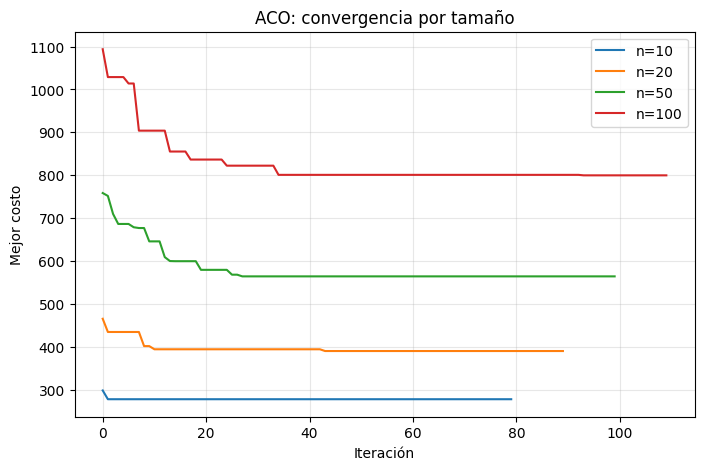

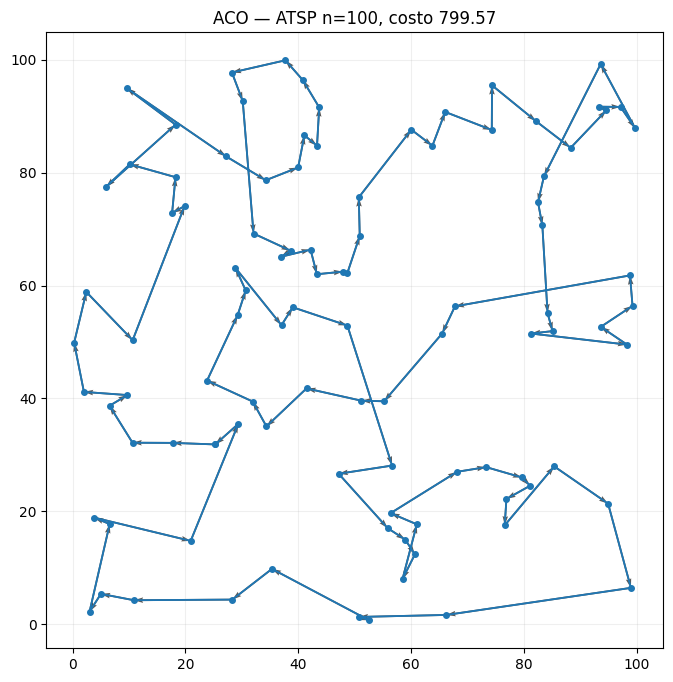

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for n in SIZES:
    ax.plot(aco_histories[n], label=f'n={n}')
ax.set_title('ACO: convergencia por tamaño')
ax.set_xlabel('Iteración')
ax.set_ylabel('Mejor costo')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

coords100, D100 = INSTANCES[100]
fig, ax = plt.subplots(figsize=(8, 8))
plot_directed_tour(
    coords100,
    aco_solutions[100],
    f'ACO — ATSP n=100, costo {tour_cost(aco_solutions[100], D100):.2f}',
    ax=ax,
)
plt.show()


## 5. Parámetros, trade-offs y complejidad

| Parámetro | Función |
|---|---|
| `alpha` | importancia de la feromona |
| `beta` | importancia del costo inmediato |
| `rho` | velocidad de evaporación |
| `n_ants` | cantidad de recorridos construidos por iteración |
| `elite_weight` | refuerzo adicional del mejor recorrido global |

El costo aproximado es $O(\text{iteraciones}\times\text{hormigas}\times n^2)$.
Una `beta` muy alta vuelve el proceso excesivamente greedy; una evaporación muy
baja puede congelar prematuramente la colonia.

## Ejercicios
1. Eliminar el depósito elitista y comparar convergencia.
2. Probar `beta` en `{1, 2, 4, 8}`.
3. Incorporar límites MAX–MIN para la feromona.
4. Ejecutar múltiples semillas y construir intervalos de resultados.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def crear_gantt_ruta(
    ruta,
    D,
    algoritmo,
    n,
    semilla_instancia,
    semilla_algoritmo=None,
    semillas_adicionales=None,
    guardar=False,
    nombre_archivo=None,
    mostrar_tabla=True
):
    
    ruta = np.asarray(ruta, dtype=int)
    D = np.asarray(D, dtype=float)

    if ruta.ndim != 1:
        raise ValueError("La ruta debe ser un arreglo unidimensional.")

    if len(ruta) != n:
        raise ValueError(
            f"La ruta tiene {len(ruta)} ciudades, pero se esperaba n={n}."
        )

    if len(np.unique(ruta)) != n:
        raise ValueError(
            "La ruta contiene ciudades repetidas."
        )

    if not np.array_equal(np.sort(ruta), np.arange(n)):
        raise ValueError(
            "La ruta no contiene exactamente las ciudades entre 0 y n-1."
        )

    if D.shape != (n, n):
        raise ValueError(
            f"La matriz D debe tener dimensiones ({n}, {n})."
        )

    ruta_cerrada = np.append(ruta, ruta[0])

    origenes = ruta_cerrada[:-1]
    destinos = ruta_cerrada[1:]

    costos_tramos = np.array([
        D[origen, destino]
        for origen, destino in zip(origenes, destinos)
    ])

    if not np.all(np.isfinite(costos_tramos)):
        raise ValueError(
            "La ruta contiene desplazamientos con costo infinito."
        )

    inicio_acumulado = np.concatenate([
        [0.0],
        np.cumsum(costos_tramos)[:-1]
    ])

    costo_acumulado = np.cumsum(costos_tramos)
    costo_total = float(costo_acumulado[-1])

    percentil_75 = float(
        np.percentile(costos_tramos, 75)
    )

    df_gantt = pd.DataFrame({
        "paso": np.arange(1, n + 1),
        "origen": origenes,
        "destino": destinos,
        "tramo": [
            f"{paso:03d}. Ciudad {origen} → Ciudad {destino}"
            for paso, origen, destino in zip(
                np.arange(1, n + 1),
                origenes,
                destinos
            )
        ],
        "inicio_acumulado": inicio_acumulado,
        "costo_tramo": costos_tramos,
        "costo_acumulado": costo_acumulado,
        "porcentaje_total": (
            costos_tramos / costo_total
        ) * 100,
        "tramo_costoso": (
            costos_tramos >= percentil_75
        )
    })

    altura = max(
        7,
        min(34, 4 + n * 0.29)
    )

    fig, ax = plt.subplots(
        figsize=(17, altura)
    )

    posiciones_y = np.arange(n)

    barras = ax.barh(
        posiciones_y,
        df_gantt["costo_tramo"],
        left=df_gantt["inicio_acumulado"],
        edgecolor="black",
        linewidth=0.7
    )


    for indice, barra in enumerate(barras):

        es_costoso = bool(
            df_gantt.loc[indice, "tramo_costoso"]
        )

        if es_costoso:
            barra.set_hatch("////")
            barra.set_linewidth(1.3)

        costo = float(
            df_gantt.loc[indice, "costo_tramo"]
        )

        inicio = float(
            df_gantt.loc[
                indice,
                "inicio_acumulado"
            ]
        )

        mostrar_valor = (
            n <= 20
            or es_costoso
        )

        if mostrar_valor:
            ax.text(
                inicio + costo / 2,
                indice,
                f"{costo:.1f}",
                ha="center",
                va="center",
                fontsize=7
            )

    ax.axvline(
        costo_total,
        linestyle="--",
        linewidth=1.6
    )

    ax.set_xlim(
        0,
        costo_total * 1.05
    )

    ax.set_yticks(posiciones_y)

    ax.set_yticklabels(
        df_gantt["tramo"],
        fontsize=7 if n >= 50 else 8
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        "Costo acumulado de la ruta"
    )

    ax.set_ylabel(
        "Secuencia de desplazamientos"
    )

    texto_semillas = (
        f"Semilla instancia: {semilla_instancia}"
    )

    if semilla_algoritmo is not None:
        texto_semillas += (
            f" | Semilla algoritmo: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            texto_semillas += (
                f" | {nombre}: {valor}"
            )

    ax.set_title(
        f"{algoritmo} — Carta Gantt de la mejor ruta ATSP\n"
        f"n={n} | costo total={costo_total:.2f}\n"
        f"{texto_semillas}",
        fontsize=13,
        pad=14
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    leyenda = [
        Patch(
            fill=False,
            edgecolor="black",
            hatch="////",
            label=(
                f"Tramo costoso ≥ P75 "
                f"({percentil_75:.2f})"
            )
        ),
        Line2D(
            [0],
            [0],
            linestyle="--",
            label=(
                f"Costo total: "
                f"{costo_total:.2f}"
            )
        )
    ]

    ax.legend(
        handles=leyenda,
        loc="lower right"
    )

    plt.tight_layout()

    if guardar:

        if nombre_archivo is None:
            nombre_normalizado = (
                algoritmo
                .lower()
                .replace(" ", "_")
                .replace("&", "and")
            )

            nombre_archivo = (
                f"gantt_{nombre_normalizado}_n{n}.png"
            )

        fig.savefig(
            nombre_archivo,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            f"Gráfico guardado: {nombre_archivo}"
        )

    print("\n" + "=" * 72)
    print(f"ALGORITMO: {algoritmo}")
    print(f"NÚMERO DE CIUDADES: {n}")
    print(f"SEMILLA DE INSTANCIA: {semilla_instancia}")

    if semilla_algoritmo is not None:
        print(
            f"SEMILLA DE ALGORITMO: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            print(
                f"{nombre.upper()}: {valor}"
            )

    print(f"COSTO TOTAL: {costo_total:.3f}")
    print(
        f"COSTO PROMEDIO POR TRAMO: "
        f"{costos_tramos.mean():.3f}"
    )
    print(
        f"TRAMO DE MAYOR COSTO: "
        f"{costos_tramos.max():.3f}"
    )
    print(
        f"PERCENTIL 75: "
        f"{percentil_75:.3f}"
    )

    print("\nRuta encontrada:")
    print(
        " → ".join(
            map(str, ruta_cerrada)
        )
    )

    if mostrar_tabla:

        columnas = [
            "paso",
            "origen",
            "destino",
            "costo_tramo",
            "costo_acumulado",
            "porcentaje_total",
            "tramo_costoso"
        ]

        display(
            df_gantt[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

        print("\nCinco tramos de mayor costo:")

        display(
            df_gantt.nlargest(
                5,
                "costo_tramo"
            )[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

    return df_gantt, fig, ax


################################################################################
CARTA GANTT ACO — n=10
Semilla instancia: 4282420734
Semilla algoritmo: 139143022
Gráfico guardado: gantt_aco_n10_instance_seed_4282420734_algorithm_seed_139143022.png

ALGORITMO: Ant Colony Optimization
NÚMERO DE CIUDADES: 10
SEMILLA DE INSTANCIA: 4282420734
SEMILLA DE ALGORITMO: 139143022
HORMIGAS: 20
ITERACIONES: 80
COSTO TOTAL: 277.348
COSTO PROMEDIO POR TRAMO: 27.735
TRAMO DE MAYOR COSTO: 76.752
PERCENTIL 75: 34.057

Ruta encontrada:
5 → 4 → 3 → 0 → 7 → 6 → 2 → 8 → 1 → 9 → 5


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,5,4,29.345,29.345,10.58,False
1,2,4,3,10.604,39.948,3.82,False
2,3,3,0,16.654,56.602,6.00,False
3,4,0,7,1.413,58.015,0.51,False
4,5,7,6,55.406,113.421,19.98,True
5,6,6,2,35.628,149.049,12.85,True
6,7,2,8,12.330,161.379,4.45,False
7,8,8,1,18.966,180.345,6.84,False
8,9,1,9,20.251,200.596,7.30,False
9,10,9,5,76.752,277.348,27.67,True



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
9,10,9,5,76.752,277.348,27.67,True
4,5,7,6,55.406,113.421,19.98,True
5,6,6,2,35.628,149.049,12.85,True
0,1,5,4,29.345,29.345,10.58,False
8,9,1,9,20.251,200.596,7.30,False


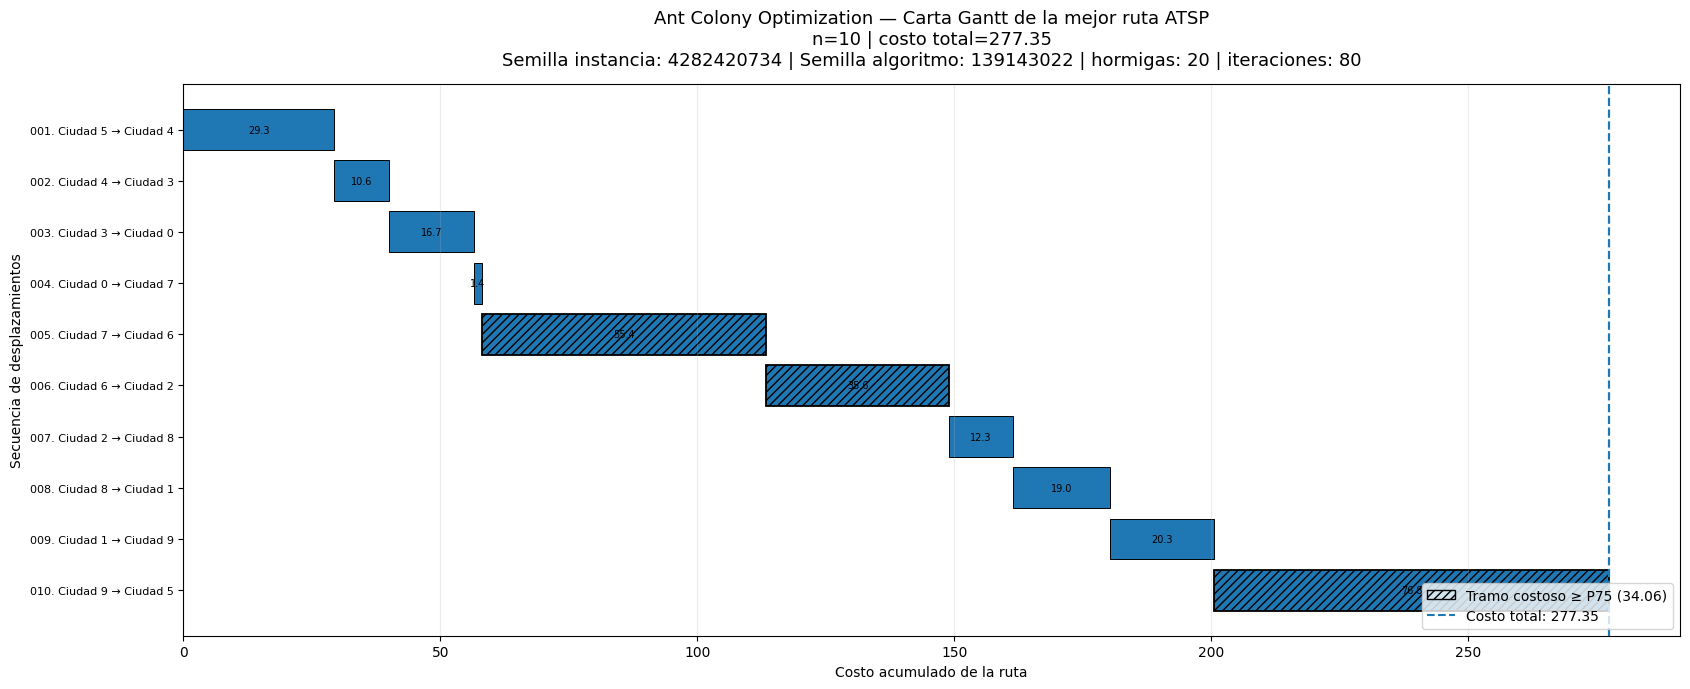


################################################################################
CARTA GANTT ACO — n=20
Semilla instancia: 1628077560
Semilla algoritmo: 4280670135
Gráfico guardado: gantt_aco_n20_instance_seed_1628077560_algorithm_seed_4280670135.png

ALGORITMO: Ant Colony Optimization
NÚMERO DE CIUDADES: 20
SEMILLA DE INSTANCIA: 1628077560
SEMILLA DE ALGORITMO: 4280670135
HORMIGAS: 30
ITERACIONES: 90
COSTO TOTAL: 389.765
COSTO PROMEDIO POR TRAMO: 19.488
TRAMO DE MAYOR COSTO: 40.874
PERCENTIL 75: 24.291

Ruta encontrada:
15 → 13 → 12 → 11 → 19 → 14 → 7 → 6 → 3 → 0 → 9 → 10 → 17 → 5 → 18 → 4 → 16 → 8 → 2 → 1 → 15


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,15,13,4.860,4.860,1.25,False
1,2,13,12,13.390,18.250,3.44,False
2,3,12,11,20.142,38.392,5.17,False
3,4,11,19,13.376,51.768,3.43,False
4,5,19,14,23.709,75.477,6.08,False
5,6,14,7,37.434,112.911,9.60,True
6,7,7,6,14.848,127.760,3.81,False
7,8,6,3,9.179,136.939,2.35,False
8,9,3,0,26.038,162.976,6.68,True
9,10,0,9,21.151,184.128,5.43,False



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
16,17,16,8,40.874,332.482,10.49,True
5,6,14,7,37.434,112.911,9.60,True
11,12,10,17,32.019,234.177,8.21,True
18,19,2,1,28.700,372.052,7.36,True
8,9,3,0,26.038,162.976,6.68,True


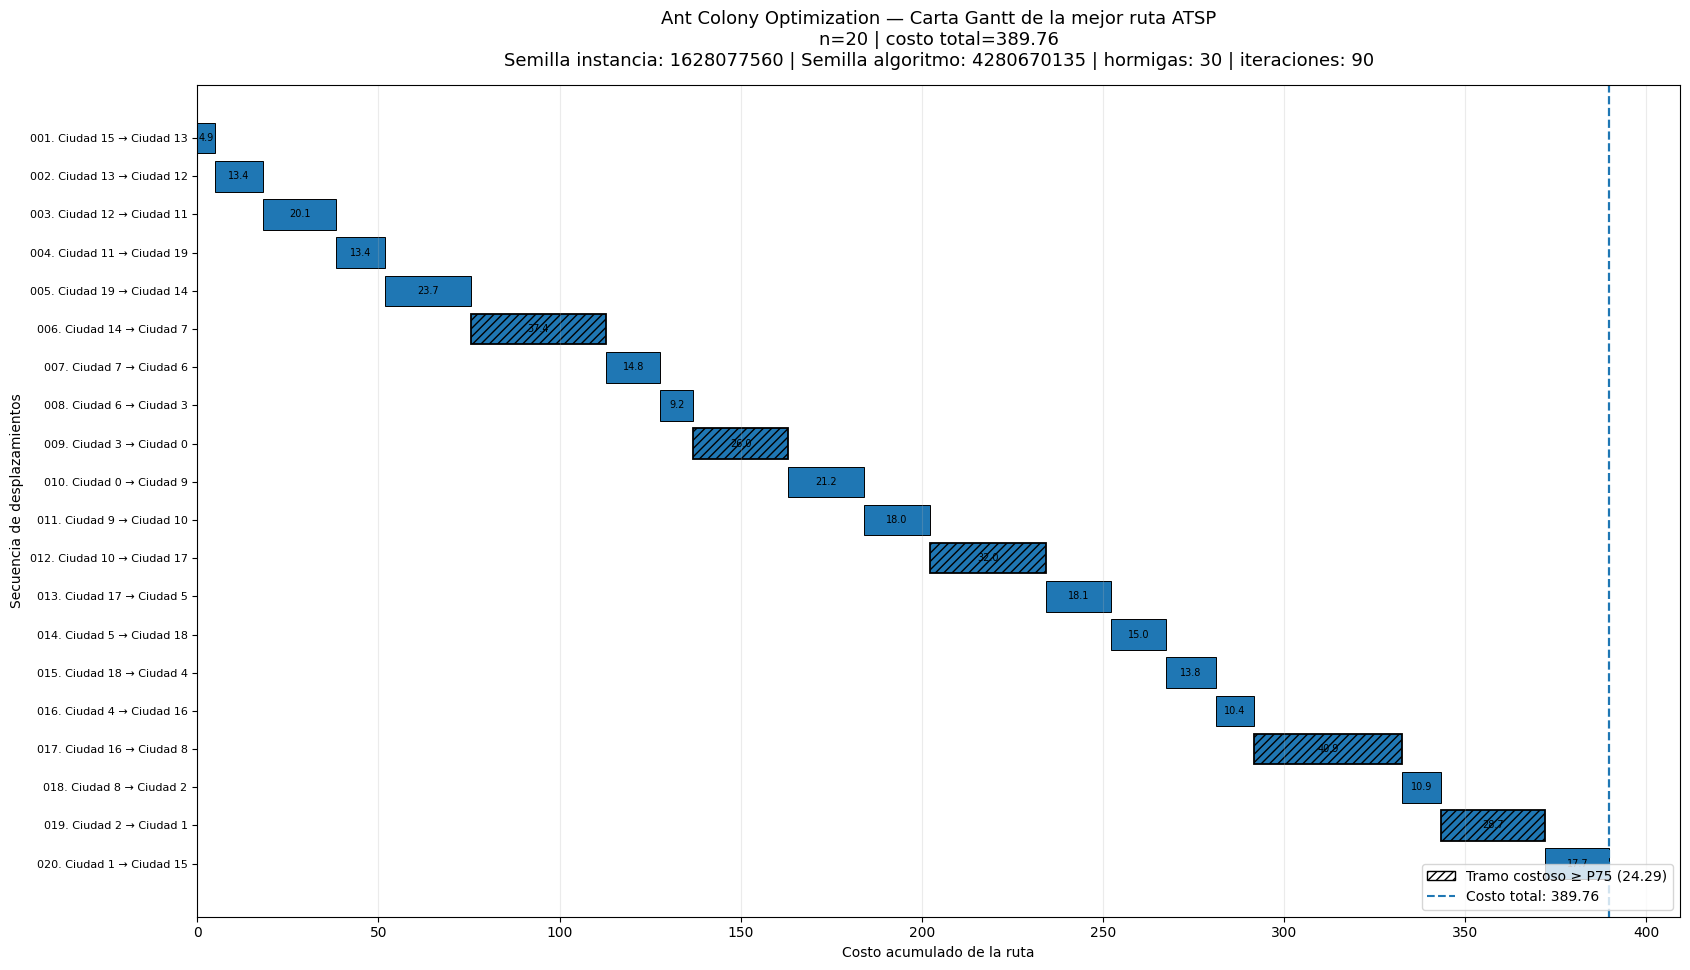


################################################################################
CARTA GANTT ACO — n=50
Semilla instancia: 3269386650
Semilla algoritmo: 1359400860
Gráfico guardado: gantt_aco_n50_instance_seed_3269386650_algorithm_seed_1359400860.png

ALGORITMO: Ant Colony Optimization
NÚMERO DE CIUDADES: 50
SEMILLA DE INSTANCIA: 3269386650
SEMILLA DE ALGORITMO: 1359400860
HORMIGAS: 40
ITERACIONES: 100
COSTO TOTAL: 563.905
COSTO PROMEDIO POR TRAMO: 11.278
TRAMO DE MAYOR COSTO: 29.077
PERCENTIL 75: 15.656

Ruta encontrada:
30 → 28 → 37 → 17 → 2 → 40 → 46 → 35 → 5 → 42 → 34 → 24 → 38 → 4 → 41 → 31 → 33 → 39 → 45 → 44 → 12 → 47 → 13 → 18 → 26 → 7 → 15 → 9 → 20 → 48 → 43 → 10 → 3 → 23 → 25 → 19 → 16 → 32 → 1 → 36 → 21 → 6 → 11 → 14 → 27 → 29 → 22 → 0 → 8 → 49 → 30


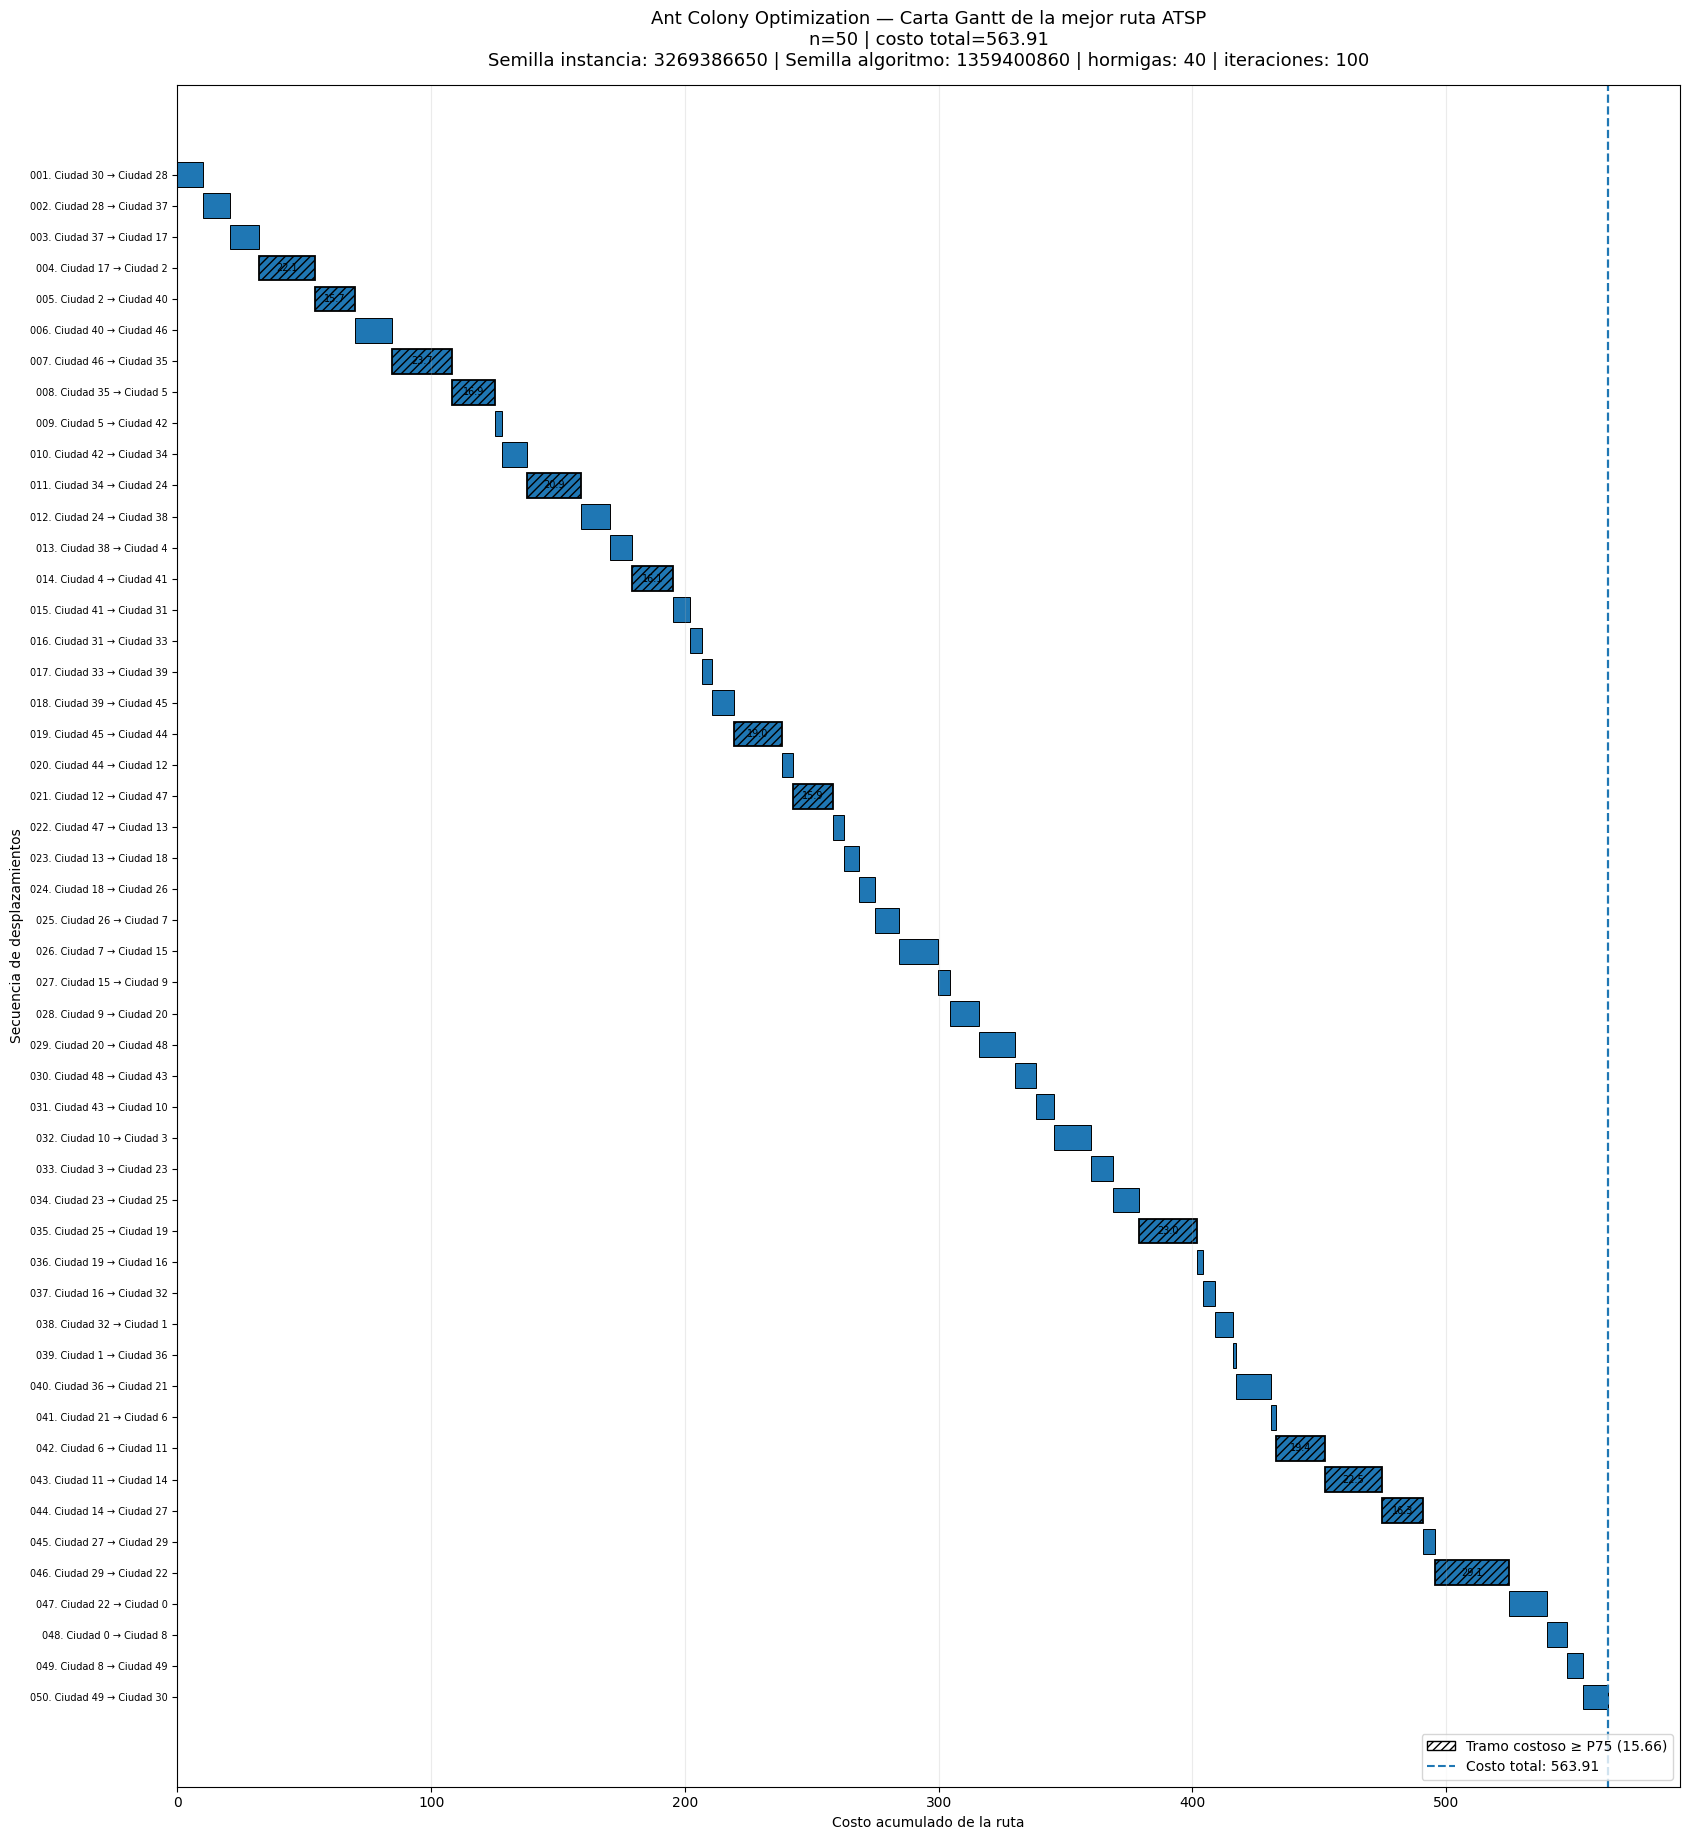


################################################################################
CARTA GANTT ACO — n=100
Semilla instancia: 3452484378
Semilla algoritmo: 2782815197
Gráfico guardado: gantt_aco_n100_instance_seed_3452484378_algorithm_seed_2782815197.png

ALGORITMO: Ant Colony Optimization
NÚMERO DE CIUDADES: 100
SEMILLA DE INSTANCIA: 3452484378
SEMILLA DE ALGORITMO: 2782815197
HORMIGAS: 45
ITERACIONES: 110
COSTO TOTAL: 799.574
COSTO PROMEDIO POR TRAMO: 7.996
TRAMO DE MAYOR COSTO: 26.303
PERCENTIL 75: 9.970

Ruta encontrada:
37 → 20 → 88 → 95 → 70 → 80 → 5 → 42 → 10 → 74 → 16 → 65 → 15 → 34 → 51 → 86 → 87 → 29 → 67 → 53 → 7 → 78 → 12 → 82 → 9 → 27 → 48 → 59 → 68 → 19 → 26 → 69 → 54 → 40 → 44 → 23 → 56 → 24 → 99 → 28 → 52 → 50 → 58 → 49 → 3 → 45 → 46 → 18 → 30 → 38 → 21 → 94 → 93 → 41 → 91 → 64 → 61 → 4 → 57 → 31 → 76 → 72 → 39 → 92 → 97 → 71 → 13 → 79 → 85 → 2 → 47 → 75 → 89 → 1 → 32 → 6 → 25 → 36 → 33 → 77 → 14 → 43 → 11 → 17 → 35 → 55 → 90 → 0 → 96 → 66 → 98 → 62 → 83 → 60 → 22 → 8 → 

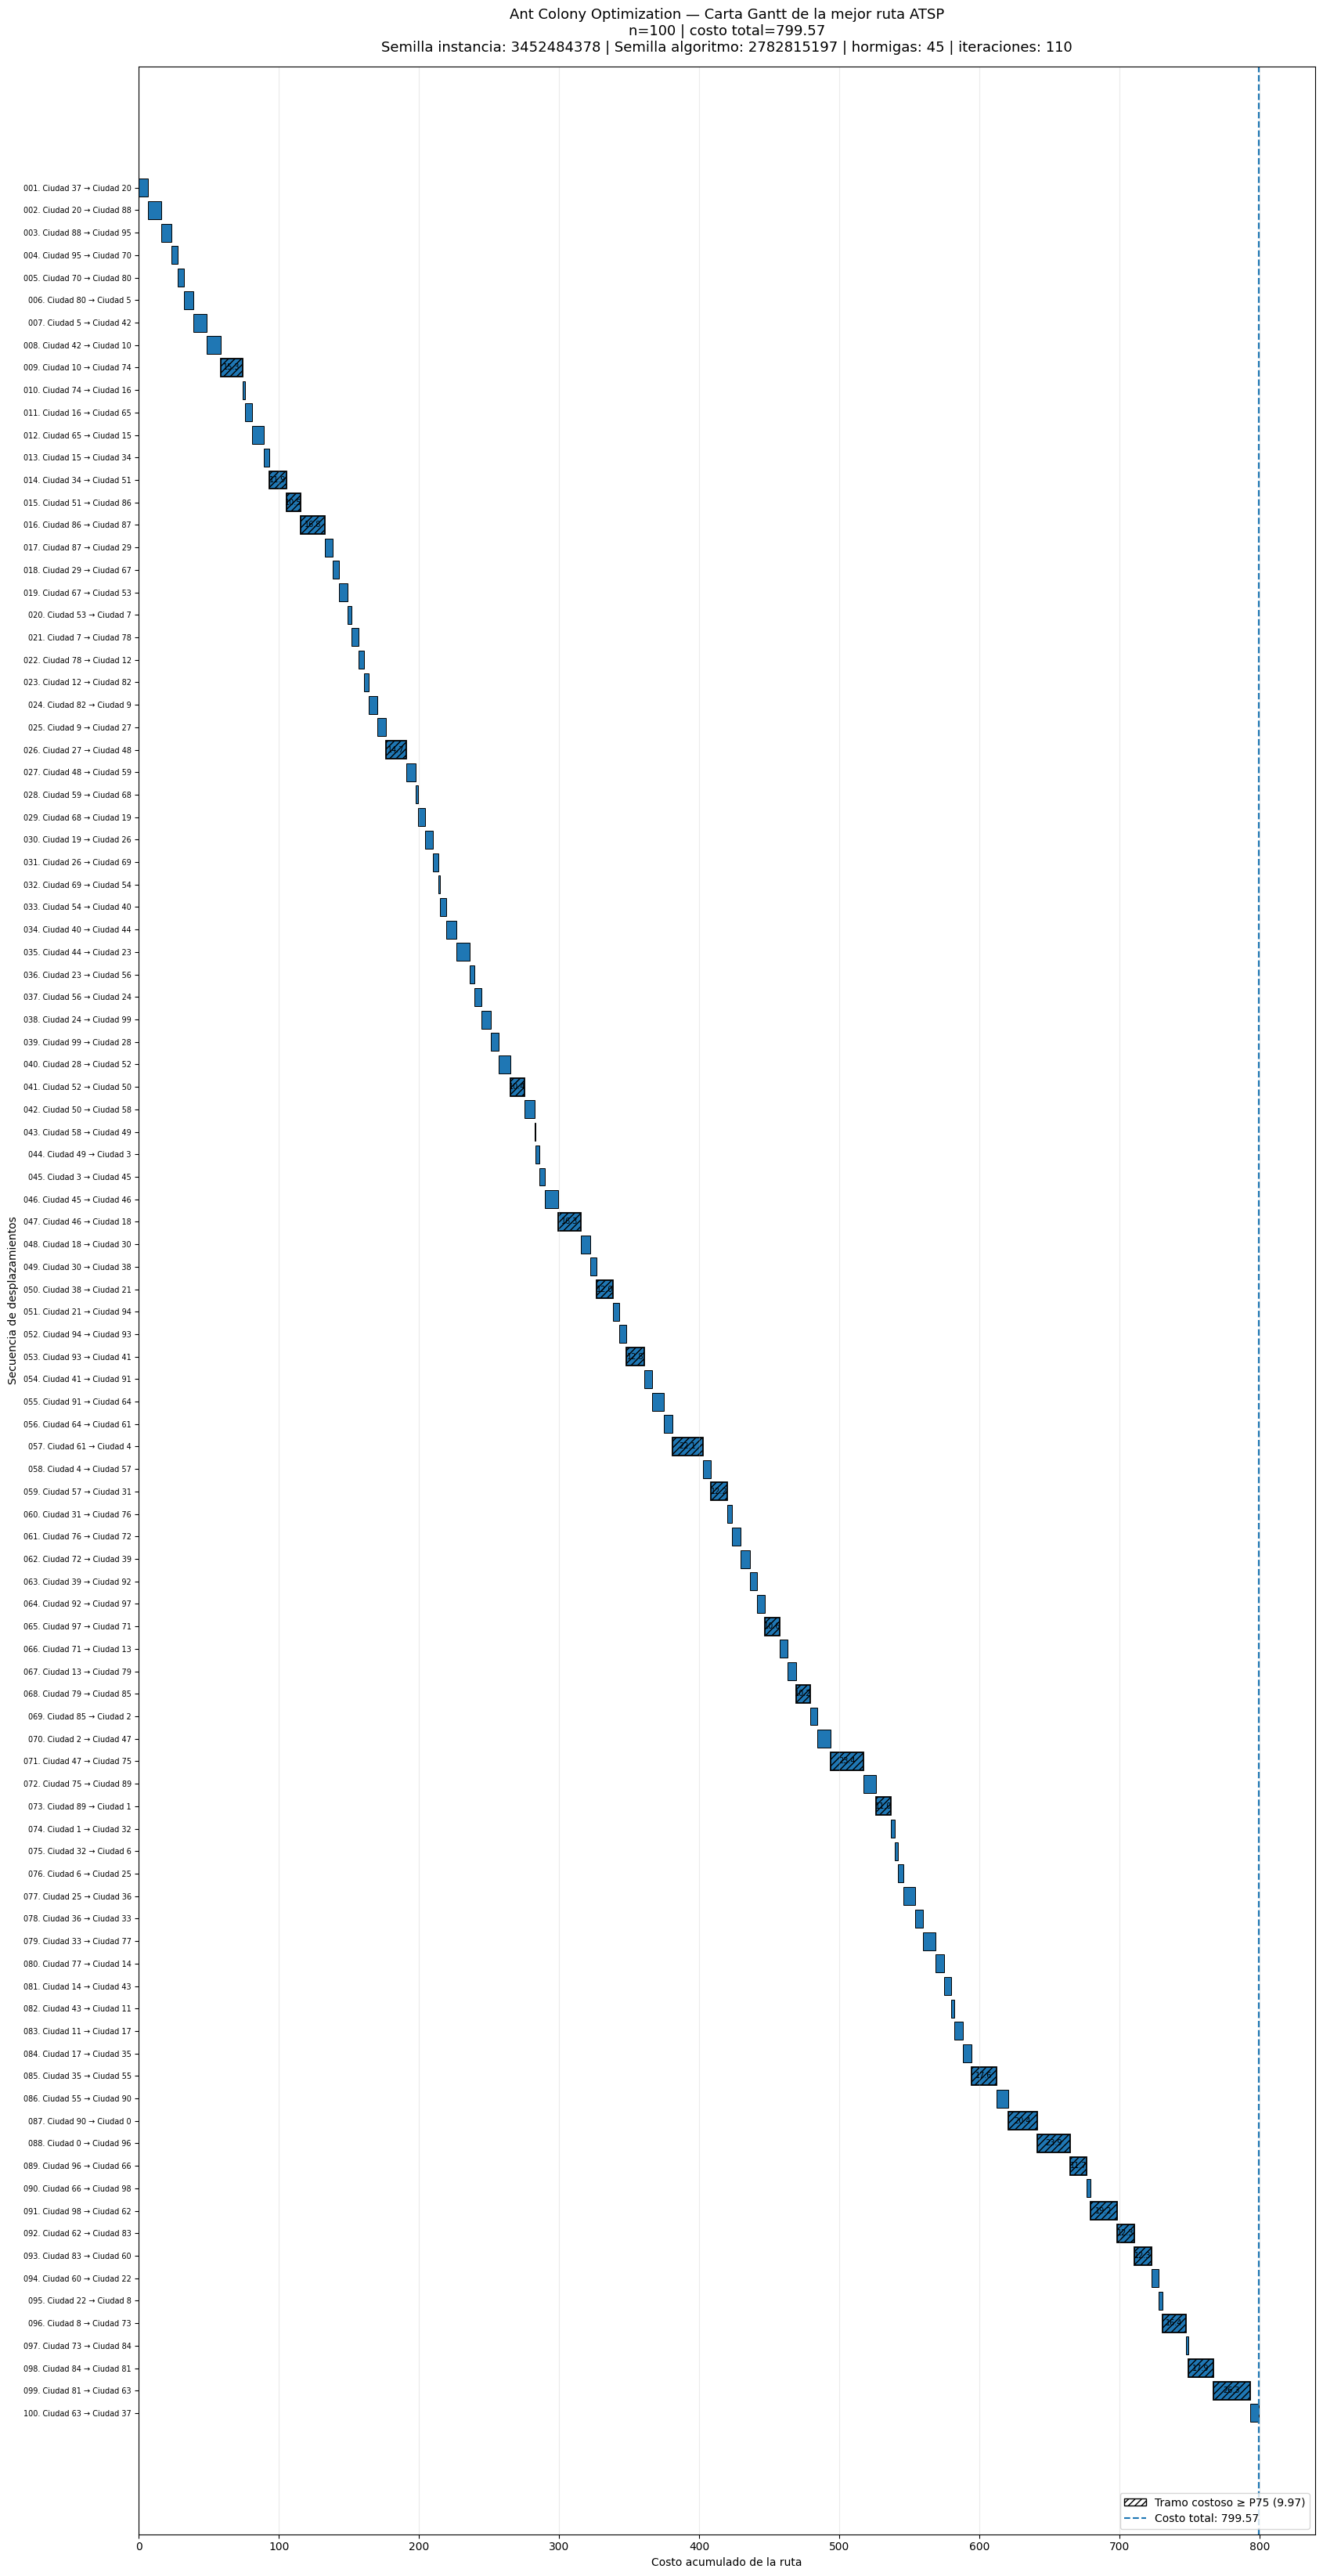

In [8]:
aco_gantt = {}

for n in SIZES:

    coords, D = INSTANCES[n]
    mejor_ruta = aco_solutions[n]

    print("\n" + "#" * 80)
    print(f"CARTA GANTT ACO — n={n}")
    print(
        f"Semilla instancia: "
        f"{INSTANCE_SEEDS[n]}"
    )
    print(
        f"Semilla algoritmo: "
        f"{ALGORITHM_SEEDS[n]}"
    )

    df_gantt, fig, ax = crear_gantt_ruta(
        ruta=mejor_ruta,
        D=D,
        algoritmo="Ant Colony Optimization",
        n=n,
        semilla_instancia=INSTANCE_SEEDS[n],
        semilla_algoritmo=ALGORITHM_SEEDS[n],
        semillas_adicionales={
            "hormigas": ACO_CONFIG[n]["ants"],
            "iteraciones": ACO_CONFIG[n]["iterations"]
        },
        guardar=True,
        nombre_archivo=(
            f"gantt_aco_n{n}_"
            f"instance_seed_{INSTANCE_SEEDS[n]}_"
            f"algorithm_seed_{ALGORITHM_SEEDS[n]}.png"
        ),
        mostrar_tabla=(n <= 20)
    )

    aco_gantt[n] = df_gantt

    plt.show()